In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os


In [16]:
IMG_SIZE = 224

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "dataset/validation",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 13207 images belonging to 15 classes.
Found 410 images belonging to 15 classes.


In [17]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])


In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [19]:
# very important for image processing
import scipy

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
413/413 [==============================] - 128s 297ms/step - loss: 0.7946 - accuracy: 0.7449 - val_loss: 0.4334 - val_accuracy: 0.8561
Epoch 2/10
413/413 [==============================] - 168s 406ms/step - loss: 0.4561 - accuracy: 0.8467 - val_loss: 0.2926 - val_accuracy: 0.9195
Epoch 3/10
413/413 [==============================] - 148s 359ms/step - loss: 0.3716 - accuracy: 0.8765 - val_loss: 0.2690 - val_accuracy: 0.9024
Epoch 4/10
413/413 [==============================] - 171s 413ms/step - loss: 0.3346 - accuracy: 0.8892 - val_loss: 0.2965 - val_accuracy: 0.8854
Epoch 5/10
413/413 [==============================] - 138s 335ms/step - loss: 0.3171 - accuracy: 0.8909 - val_loss: 0.2737 - val_accuracy: 0.8951
Epoch 6/10
413/413 [==============================] - 162s 392ms/step - loss: 0.2991 - accuracy: 0.8987 - val_loss: 0.2876 - val_accuracy: 0.9073
Epoch 7/10
413/413 [==============================] - 148s 355ms/step - loss: 0.2711 - accuracy: 0.9072 - val_loss: 0.3009 -

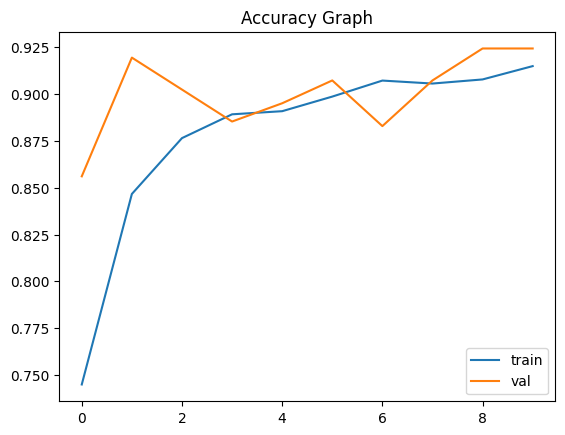

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy Graph")
plt.show()


In [26]:
# saving the model

model.save('Plant_model.keras')

In [28]:
# not necessary, install dataset first
img = tf.keras.preprocessing.image.load_img(
    "dataset/my_test/t15.jpg",
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
class_name = train_data.class_indices

print(pred)
print(class_name)


1/1 [==============================] - 0s 384ms/step
[[1.8048409e-10 1.8424068e-08 1.6347392e-13 6.6515118e-12 1.7480976e-10
  9.4732124e-09 3.6217910e-04 1.3071856e-07 3.2458492e-04 1.2544549e-06
  9.9720436e-01 7.0183538e-04 1.0416983e-07 9.7421962e-06 1.3957063e-03]]
{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [31]:
# out = max(pred)
# for i in range(len(pred)):
#     if(pred[i]==out):
#         break

i = np.argmax(pred[0])

category = [ key for key, value in class_name.items() if value==i]
print(category)

['Tomato_Spider_mites_Two_spotted_spider_mite']
